# MNIST Baseline ANN & Experiment Tracking

College deep learning assignment notebook.

In [23]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

## Section 1: Load Dataset

In [24]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (60000, 28, 28)
X_test.shape: (10000, 28, 28)


## Section 2: Normalize and Flatten

In [25]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

print("X_train.shape:", X_train.shape)

X_train.shape: (60000, 784)


## Section 3: Build Baseline ANN

In [26]:
def build_model(lr=0.001):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(784,)),
            keras.layers.Dense(128, activation="relu"),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## Section 4: Manual Experiment Tracking

In [27]:
experiment_log = []


def run_experiment(exp_id, lr, epochs, batch_size):
    model = build_model(lr)
    start_time = datetime.now()
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    end_time = datetime.now()
    training_time_sec = (end_time - start_time).total_seconds()

    _, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    val_accuracy = max(history.history["val_accuracy"])

    experiment_log.append(
        {
            "exp_id": exp_id,
            "learning_rate": lr,
            "epochs": epochs,
            "batch_size": batch_size,
            "val_accuracy": round(val_accuracy, 4),
            "test_accuracy": round(test_accuracy, 4),
            "training_time_sec": round(training_time_sec, 2),
        }
    )
    return model

## Section 5: Run Multiple Configurations

In [28]:
run_experiment("EXP-01", lr=0.001, epochs=10, batch_size=32)
run_experiment("EXP-02", lr=0.01, epochs=10, batch_size=32)
run_experiment("EXP-03", lr=0.0001, epochs=10, batch_size=64)

results_df = pd.DataFrame(experiment_log)
log_path = project_root / "experiment_log.csv"
results_df.to_csv(log_path, index=False)
print(results_df)

   exp_id  learning_rate  epochs  batch_size  val_accuracy  test_accuracy  \
0  EXP-01         0.0010      10          32        0.9817         0.9786   
1  EXP-02         0.0100      10          32        0.9703         0.9630   
2  EXP-03         0.0001      10          64        0.9725         0.9624   

   training_time_sec  
0              11.27  
1              11.29  
2               6.54  


## Section 6: Save Best Model

In [29]:
best_row = results_df.loc[results_df["test_accuracy"].idxmax()]

best_model = build_model(lr=best_row["learning_rate"])
best_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=int(best_row["epochs"]),
    batch_size=int(best_row["batch_size"]),
    verbose=0,
)

model_path = project_root / "models" / "baseline_ann.keras"
best_model.save(model_path)
print(f"Saved best model to: {model_path} (Keras .keras format)")
print("Baseline Model Trained Successfully")
print("Results Saved to experiment_log.csv")

Saved best model to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 2/baseline-model-tracking/models/baseline_ann.keras (Keras .keras format)
Baseline Model Trained Successfully
Results Saved to experiment_log.csv


## Section 7: Results Summary

### Experiment Comparison

In [30]:
logged_results = pd.read_csv(project_root / "experiment_log.csv")

comparison_table = logged_results[
    ["exp_id", "learning_rate", "epochs", "batch_size", "test_accuracy"]
].rename(
    columns={
        "exp_id": "Exp ID",
        "learning_rate": "Learning Rate",
        "epochs": "Epochs",
        "batch_size": "Batch Size",
        "test_accuracy": "Test Accuracy",
    }
)

comparison_table

,Exp ID,Learning Rate,Epochs,Batch Size,Test Accuracy
0,EXP-01,0.0010,10,32,0.9786
1,EXP-02,0.0100,10,32,0.9630
2,EXP-03,0.0001,10,64,0.9624


### Best Configuration

In [31]:
best_config = logged_results.loc[logged_results["test_accuracy"].idxmax()]
print("Best Configuration (highest test_accuracy):")
print(best_config.to_string())

Best Configuration (highest test_accuracy):
exp_id               EXP-01
learning_rate         0.001
epochs                   10
batch_size               32
val_accuracy         0.9817
test_accuracy        0.9786
training_time_sec     11.27


### Test Accuracy Comparison Chart

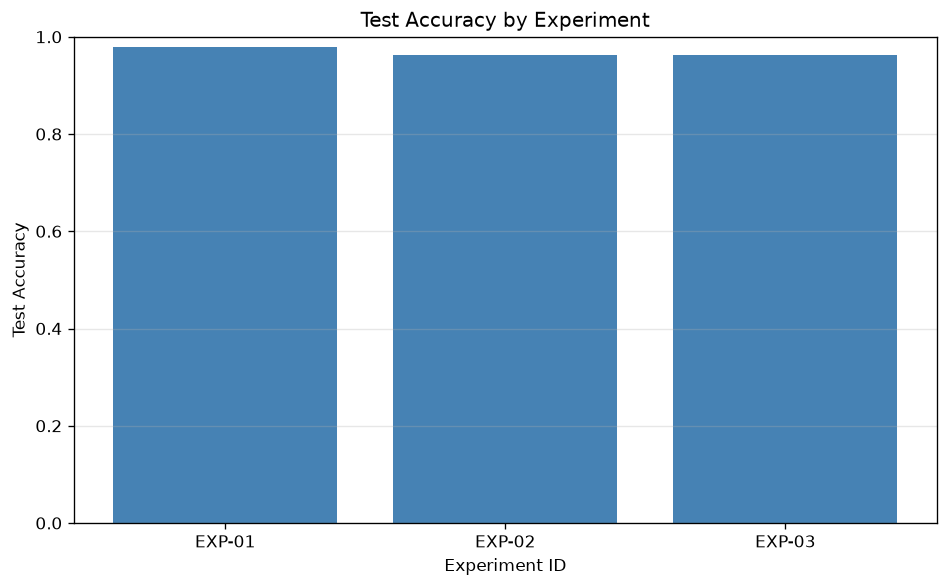

In [32]:
from io import BytesIO

from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(logged_results["exp_id"], logged_results["test_accuracy"], color="steelblue")
ax.set_title("Test Accuracy by Experiment")
ax.set_xlabel("Experiment ID")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
display(Image(data=buffer.getvalue()))

### Completion Checklist

- [x] Baseline Model Trained Successfully
- [x] Experiments Logged
- [x] Best Configuration Identified
- [x] Results Saved to experiment_log.csv